In [7]:
# ============================================================
# CELL 1 — Install dependencies (run once, then you can comment out)
# ============================================================
import sys
!{sys.executable} -m pip install -q torch torchvision opencv-python ftfy regex tqdm matplotlib pillow ipywidgets
!{sys.executable} -m pip install -q git+https://github.com/openai/CLIP.git


In [8]:
# ============================================================
# CELL 2 — Imports and CLIP model
# ============================================================
import io
import time
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import clip
import ipywidgets as widgets
from IPython.display import display

# Device selection (CUDA > Apple MPS > CPU)
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Using device: {device}")

print("Loading CLIP model...")
model, preprocess = clip.load("ViT-B/32", device=device)
print("Model loaded successfully!")



Using device: cuda
Loading CLIP model...
Model loaded successfully!


In [12]:
# ============================================================
# CELL 3 — Show upload button. Run this, then pick your image.
# ============================================================
uploader = widgets.FileUpload(accept='image/*', multiple=False)
display(uploader)
print("Click the button above and choose an image, then run the next cell.")

FileUpload(value=(), accept='image/*', description='Upload')

Click the button above and choose an image, then run the next cell.


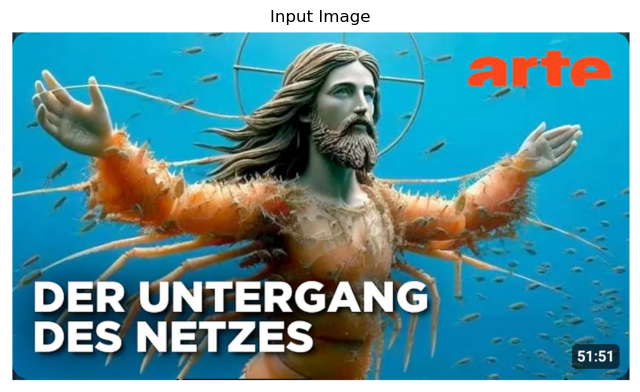

Analyzing image: arte_Doku1.png, size: 1279x726


In [13]:
# ============================================================
# CELL 4 — Load the uploaded image
# ============================================================
if not uploader.value:
    raise RuntimeError("No file uploaded yet — use the button in the previous cell first.")

# ipywidgets 8+ returns a tuple of dicts; older versions return a dict keyed by filename
if isinstance(uploader.value, tuple):
    entry = uploader.value[0]
    image_path = entry['name']
    content = entry['content']
else:
    image_path = next(iter(uploader.value))
    content = uploader.value[image_path]['content']

image = Image.open(io.BytesIO(content)).convert("RGB")

plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.title("Input Image")
plt.axis('off')
plt.show()
print(f"Analyzing image: {image_path}, size: {image.width}x{image.height}")

In [14]:
# ============================================================
# CELL 5 — Heatmap function
# ============================================================
def enhanced_concept_heatmap(image, concept, patch_sizes=[64, 96, 128], strides=[16, 32, 48]):
    # Resize large images for performance
    width, height = image.size
    max_dim = 512
    if max(width, height) > max_dim:
        scale = max_dim / max(width, height)
        new_size = (int(width * scale), int(height * scale))
        img = image.resize(new_size, Image.LANCZOS)
        print(f"Resized to {new_size} for processing")
    else:
        img = image

    heatmap = np.zeros((img.height, img.width))
    counts = np.zeros((img.height, img.width))

    prompt_variations = [concept, f"a {concept}", f"the {concept}"]
    text_tokens = clip.tokenize(prompt_variations).to(device)

    for patch_size, stride in zip(patch_sizes, strides):
        print(f"  Processing with patch size {patch_size}px, stride {stride}px")

        for y in range(0, img.height - patch_size + 1, stride):
            for x in range(0, img.width - patch_size + 1, stride):
                patch = img.crop((x, y, x + patch_size, y + patch_size))
                patch_tensor = preprocess(patch).unsqueeze(0).to(device)

                with torch.no_grad():
                    image_features = model.encode_image(patch_tensor)
                    image_features /= image_features.norm(dim=-1, keepdim=True)

                    text_features = model.encode_text(text_tokens)
                    text_features /= text_features.norm(dim=-1, keepdim=True)

                    similarities = (100.0 * image_features @ text_features.T)
                    max_similarity = float(similarities.max().item())

                weight = 1.0 / patch_size
                heatmap[y:y+patch_size, x:x+patch_size] += max_similarity * weight
                counts[y:y+patch_size, x:x+patch_size] += weight

    heatmap = np.divide(heatmap, counts, out=np.zeros_like(heatmap), where=counts != 0)

    # Percentile-based normalization
    p_low, p_high = np.percentile(heatmap, [5, 95])
    heatmap = np.clip((heatmap - p_low) / (p_high - p_low + 1e-8), 0, 1)

    # Non-linear contrast
    heatmap = np.power(heatmap, 1.5)

    # Adaptive smoothing
    kernel_size = max(3, min(31, int(min(img.width, img.height) / 20)))
    if kernel_size % 2 == 0:
        kernel_size += 1
    heatmap = cv2.GaussianBlur(heatmap, (kernel_size, kernel_size), 0)

    if img.size != image.size:
        heatmap = cv2.resize(heatmap, (image.width, image.height))

    return heatmap


Analyzing concept: 'man riding dinosaur'
Resized to (512, 290) for processing
  Processing with patch size 96px, stride 32px


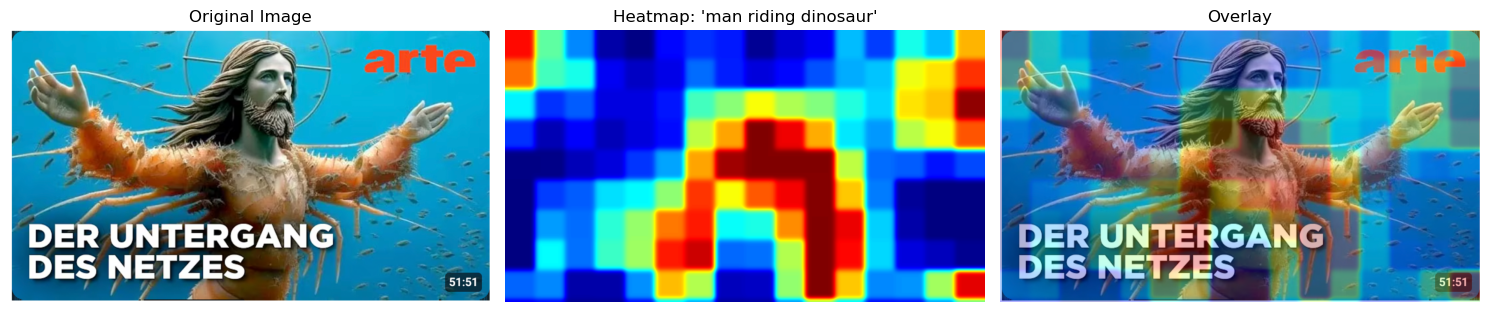

Processed in 0.6 seconds

Analyzing concept: 'man's face'
Resized to (512, 290) for processing
  Processing with patch size 96px, stride 32px


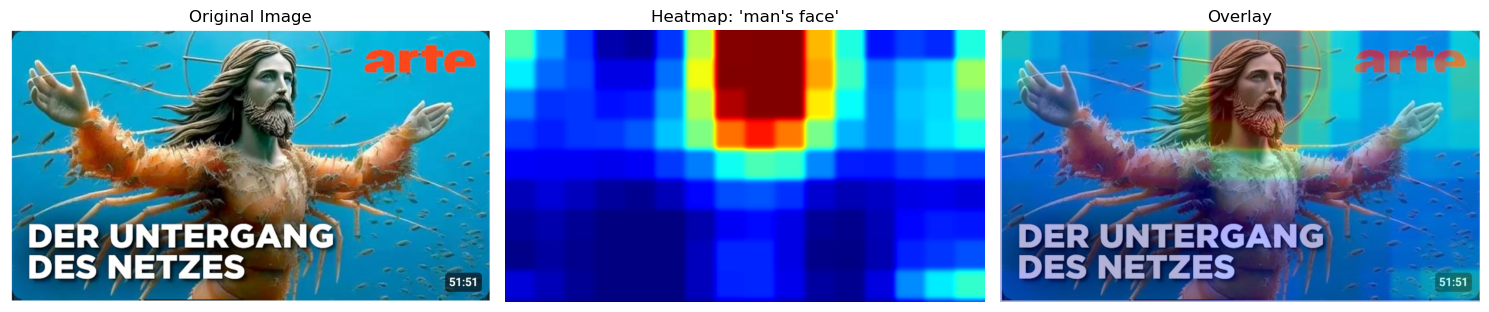

Processed in 0.5 seconds

Analyzing concept: 'green dinosaur'
Resized to (512, 290) for processing
  Processing with patch size 96px, stride 32px


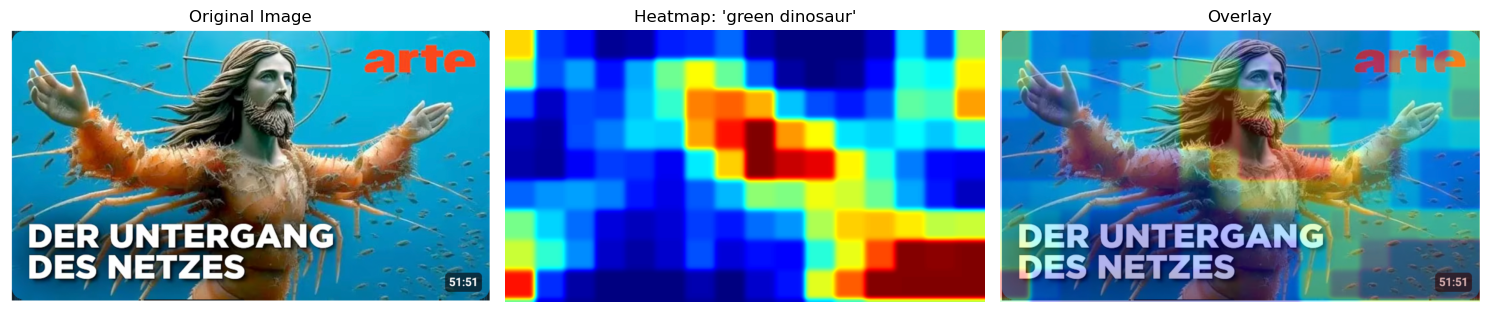

Processed in 0.5 seconds

Analyzing concept: 'dinosaur head'
Resized to (512, 290) for processing
  Processing with patch size 96px, stride 32px


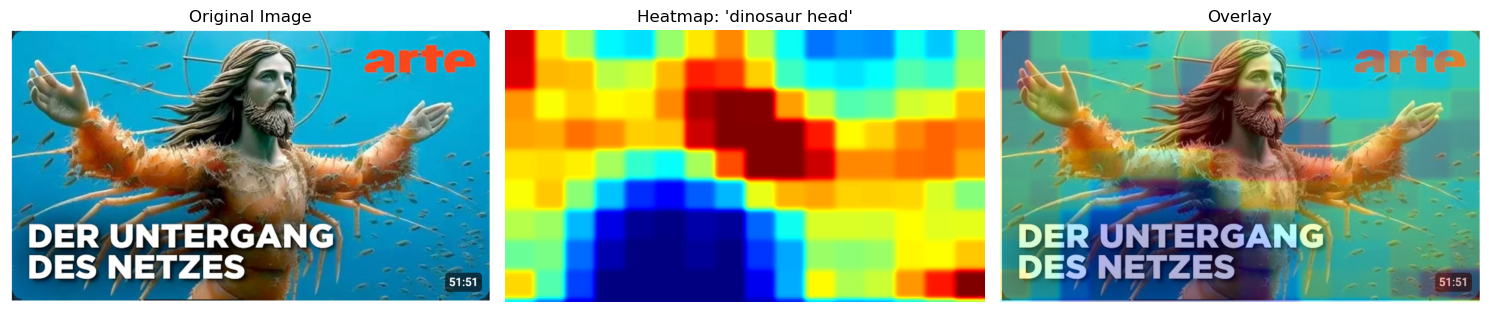

Processed in 0.5 seconds

Analyzing concept: 'hat'
Resized to (512, 290) for processing
  Processing with patch size 96px, stride 32px


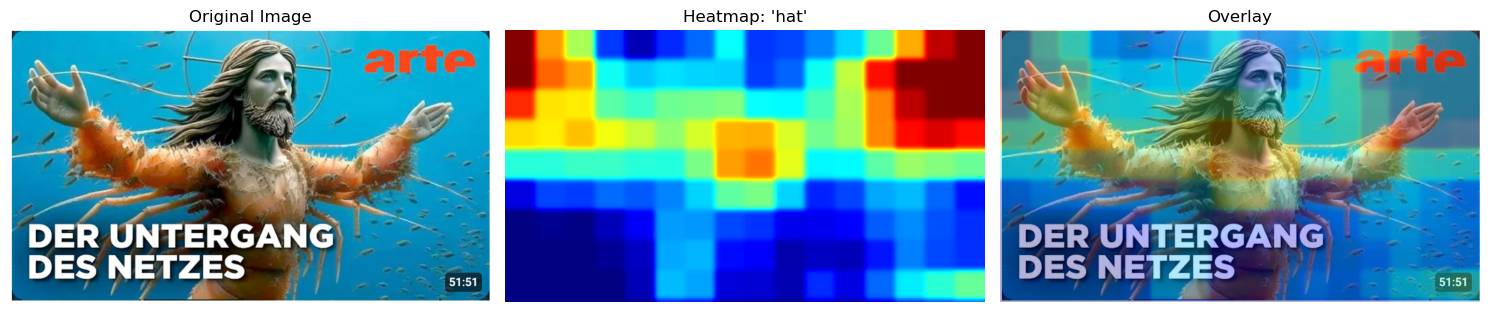

Processed in 0.5 seconds

Analysis complete!


In [17]:
# ============================================================
# CELL 6 — Run analysis for a list of concepts
# ============================================================
concepts = [
    "man riding dinosaur",
    "man's face",
    "green dinosaur",
    "dinosaur head",
    "hat",
]

results = {}
for concept in concepts:
    print(f"\nAnalyzing concept: '{concept}'")
    start = time.time()

    # Fast single-scale. For best accuracy, call without kwargs to use defaults.
    heatmap = enhanced_concept_heatmap(image, concept, patch_sizes=[96], strides=[32])

    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    results[concept] = {'heatmap': heatmap, 'colored': heatmap_colored}

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(image); plt.title("Original Image"); plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_colored); plt.title(f"Heatmap: '{concept}'"); plt.axis('off')

    plt.subplot(1, 3, 3)
    overlay = cv2.addWeighted(np.array(image), 0.7, heatmap_colored, 0.3, 0)
    plt.imshow(overlay); plt.title("Overlay"); plt.axis('off')

    plt.tight_layout()
    plt.show()

    print(f"Processed in {time.time() - start:.1f} seconds")

print("\nAnalysis complete!")